## 라쏘 모델

Lasso는 중요한 변수를 선택하고 덜 중요한 변수의 계수를 0으로 만드는 즉, 피처 선택의 특성을 지니는 모델이다. 이는 과적합을 방지하는 데 도움을 준다.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

train_df = pd.read_csv('movies_train.csv')
test_df = pd.read_csv('movies_test.csv')
submission_df = pd.read_csv('submission.csv')

In [ ]:
print("훈련 데이터 정보:")
train_df.info()

print("\n테스트 데이터 정보:")
test_df.info()

훈련 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB

테스트 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          -------

여러 범주형 컬럼과 결측치를 확인 가능.
- dtype : object (범주형)
- non-null count < entry 수

범주형 특성에는 원-핫 인코딩을 적용하고, 수치형 특성은 스케일링하여 처리.

In [ ]:
# 타겟 변수 분리
X = train_df.drop('box_off_num', axis=1)
y = train_df['box_off_num']

# 범주형 및 수치형 특성 식별
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# 수치형 특성 전처리: 결측치 처리 후 표준 스케일링
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # 결측치를 평균으로 채움
    ('scaler', StandardScaler())
])

# 범주형 특성 전처리: 원-핫 인코딩
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# ColumnTransformer를 사용하여 수치형 및 범주형 특성 전처리 파이프라인 생성
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # 다른 컬럼은 그대로 둠
)

In [ ]:
# Lasso 모델 하이퍼파라미터 튜닝
# Lasso 모델을 포함하는 파이프라인 정의
lasso_pipeline_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(random_state=42, max_iter=10000)) # ConvergenceWarning 방지를 위해 max_iter 증가
])

# 튜닝할 alpha 값의 범위 설정 (0.001부터 10까지 50개의 로그 스케일 값)
param_grid = {
    'regressor__alpha': np.logspace(-3, 1, 50)
}

# GridSearchCV 설정 및 실행
grid_search = GridSearchCV(
    lasso_pipeline_tuned,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X, y)

# 최적의 하이퍼파라미터와 교차 검증 성능 출력
print(f"\n최적의 alpha 값: {grid_search.best_params_['regressor__alpha']:.4f}")
print(f"최고 교차 검증 MSE (음수): {grid_search.best_score_:.2f}")

# 최적 모델 저장
best_lasso_model = grid_search.best_estimator_

# 튜닝된 모델의 훈련 데이터 성능 평가
y_pred_train_tuned = best_lasso_model.predict(X)
mse_train_tuned = mean_squared_error(y, y_pred_train_tuned)
r2_train_tuned = r2_score(y, y_pred_train_tuned)

print(f"\n튜닝된 모델의 훈련 데이터 MSE: {mse_train_tuned:.2f}")
print(f"튜닝된 모델의 훈련 데이터 R-squared: {r2_train_tuned:.2f}")
print("하이퍼파라미터 튜닝 및 훈련 데이터 성능 평가 완료.")


최적의 alpha 값: 1.0481
최고 교차 검증 MSE (음수): -2401691954488.48

튜닝된 모델의 훈련 데이터 MSE: 292386.63
튜닝된 모델의 훈련 데이터 R-squared: 1.00
하이퍼파라미터 튜닝 및 훈련 데이터 성능 평가 완료.


In [ ]:
# 여러 alpha 값에 대한 교차 검증 RMSE 비교
print("\n--- 각 alpha 값에 대한 5-폴드 교차 검증 평균 RMSE 비교 ---")
alphas_to_compare = [0.01, 0.1, 1.0, grid_search.best_params_['regressor__alpha'], 5.0]
rmse_results = {}

for alpha_val in alphas_to_compare:
    current_lasso_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=alpha_val, random_state=42, max_iter=2000)) # 일관성을 위해 max_iter 추가
    ])

    # 5-폴드 교차 검증 수행
    cv_scores = cross_val_score(
        current_lasso_pipeline,
        X, y,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    # RMSE 계산 및 저장
    rmse_scores = np.sqrt(-cv_scores)
    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)

    rmse_results[alpha_val] = mean_rmse
    print(f"alpha={alpha_val:.4f}일 때 5-폴드 교차 검증 평균 RMSE: {mean_rmse:.2f} (표준편차: {std_rmse:.2f})")


--- 각 alpha 값에 대한 5-폴드 교차 검증 평균 RMSE 비교 ---
alpha=0.0100일 때 5-폴드 교차 검증 평균 RMSE: 1550734.83 (표준편차: 339250.25)
alpha=0.1000일 때 5-폴드 교차 검증 평균 RMSE: 1550725.95 (표준편차: 339258.10)
alpha=1.0000일 때 5-폴드 교차 검증 평균 RMSE: 1506029.59 (표준편차: 367875.51)
alpha=1.0481일 때 5-폴드 교차 검증 평균 RMSE: 1502934.64 (표준편차: 370989.26)
alpha=5.0000일 때 5-폴드 교차 검증 평균 RMSE: 1570457.26 (표준편차: 409628.94)


In [ ]:
# 최적 모델의 특성 계수 분석
# 최적 모델 내의 preprocessor를 사용하여 특성 이름 가져오기
fitted_preprocessor_from_best_model = best_lasso_model.named_steps['preprocessor']
onehot_features_names = fitted_preprocessor_from_best_model.named_transformers_['cat'].get_feature_names_out(categorical_features)
numerical_features_names = numerical_features.tolist()
all_features_names = numerical_features_names + list(onehot_features_names)

# 최적 모델의 계수 추출
best_lasso_coefficients = best_lasso_model.named_steps['regressor'].coef_

# 특성 중요도 DataFrame 생성 및 정렬
feature_importance = pd.DataFrame({
    'Feature': all_features_names,
    'Coefficient': best_lasso_coefficients
})
feature_importance['Absolute_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

pd.set_option('display.float_format', lambda x: '%.2f' % x) # 숫자 표기법 설정
display(feature_importance.head(10))

print("\n--- 여러 alpha 값에 따른 피처별 회귀 계수 비교 (상위 10개 특성) ---")
coeff_lasso_df = pd.DataFrame(index=all_features_names)

# 각 alpha 값에 대해 모델 학습 및 계수 추출
for alpha_val in alphas_to_compare:
    current_lasso_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=alpha_val, random_state=42, max_iter=5000))
    ])
    current_lasso_pipeline.fit(X, y)
    coefficients = current_lasso_pipeline.named_steps['regressor'].coef_
    coeff_lasso_df[f'alpha={alpha_val:.4f}'] = pd.Series(coefficients, index=all_features_names)

# 상위 10개 특성만 비교 DataFrame에서 추출하여 출력
top_10_features_for_comparison = feature_importance.head(10)['Feature'].tolist()
display(coeff_lasso_df.loc[top_10_features_for_comparison])

,Feature,Coefficient,Absolute_Coefficient
66,title_국제시장,11678895.25,11678895.25
16,title_7번방의 선물,11630361.84,11630361.84
259,title_변호인,10379307.32,10379307.32
64,"title_광해, 왕이 된 남자",10264012.96,10264012.96
150,title_도둑들,9250411.13,9250411.13
304,title_설국열차,9009565.12,9009565.12
366,title_암살,8324999.51,8324999.51
63,title_관상,7746366.77,7746366.77
322,title_수상한 그녀,6450801.78,6450801.78
430,title_은밀하게 위대하게,5545164.69,5545164.69



--- 여러 alpha 값에 따른 피처별 회귀 계수 비교 (상위 10개 특성) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 202079486121.56863, tolerance: 200162162969.76883
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 298368667034.46747, tolerance: 200162162969.76883
  model = cd_fast.sparse_enet_coordinate_descent(


,alpha=0.0100,alpha=0.1000,alpha=1.0000,alpha=1.0481,alpha=5.0000
title_국제시장,11175167.48,11175030.50,11453374.12,11619696.85,12675846.74
title_7번방의 선물,10385779.53,10385669.26,11435915.26,11588161.78,11810260.53
title_변호인,9364596.30,9364352.23,10222881.70,10346511.02,10441256.36
"title_광해, 왕이 된 남자",9513407.49,9513386.71,9951331.29,10194783.59,10822176.88
title_도둑들,9307396.73,9307246.69,9294459.68,9273393.70,4271731.43
title_설국열차,7769292.83,7769052.25,8890571.61,8991357.81,8876673.17
title_암살,7947108.86,7946858.88,8227776.69,8301804.15,3923994.08
title_관상,6143803.06,6143554.71,7545430.50,7703496.46,7804331.32
title_수상한 그녀,5769790.64,5769541.08,6405111.22,6430601.15,6678920.31
title_은밀하게 위대하게,4587265.77,4587028.38,5360867.71,5499014.99,5517382.41


In [ ]:
# 테스트 데이터 예측
X_test_submission = test_df.copy() # 테스트 데이터를 복사
predictions_tuned = best_lasso_model.predict(X_test_submission) # 최적 모델로 예측 수행
predictions_tuned[predictions_tuned < 0] = 0 # 예측값이 음수인 경우 0으로 설정

submission_df['box_off_num'] = predictions_tuned # 제출 DataFrame에 예측 결과 추가
submission_df.to_csv('lasso_tuned_final_submission.csv', index=False) # CSV 파일로 저장

display(submission_df.head())

,title,box_off_num
0,용서는 없다,951087.18
1,아빠가 여자를 좋아해,1227725.06
2,하모니,1889434.11
3,의형제,1510395.12
4,평행 이론,933651.94


**(참고)**

모든 피처의 회귀 계수를 나타낸 DataFrame으로, 전체를 보면 실제로는 많은 특성들의 계수가 0이거나 0에 아주 가까운 작은 값인 것을 확인할 수 있음. 이에 상위 10개의 가장 영향력 있는 특성들만 뽑아서 라쏘 모델 적용.

In [ ]:
# 모든 피처의 회귀 계수 확인
# pandas display 옵션을 조정하여 모든 행과 열을 볼 수 있도록 합니다.
pd.set_option('display.max_rows', None) # 모든 행 표시
pd.set_option('display.max_columns', None) # 모든 열 표시

display(coeff_lasso_df)

# 원래대로 옵션 초기화 (선택 사항)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')


,alpha=0.0100,alpha=0.1000,alpha=1.0000,alpha=1.0481,alpha=5.0000
time,806247.37,806239.90,140865.25,62892.58,4110.94
dir_prev_bfnum,271873.88,271878.72,238498.84,221490.41,53235.17
dir_prev_num,206441.07,206438.68,111692.80,88569.93,14737.83
num_staff,335693.45,335696.94,468647.15,452403.54,224393.06
num_actor,67944.89,67945.58,11789.67,7998.15,7518.08
title_ 개를 훔치는 완벽한 방법,-1066873.13,-1066607.12,-403362.86,-302725.27,-9546.09
"title_1789, 바스티유의 연인들",-1563469.85,-1563176.89,0.00,0.00,-0.00
title_18: 우리들의 성장 느와르,-573124.12,-572846.41,-418064.90,-386306.11,-391905.42
"title_1999, 면회",384210.75,384147.12,0.00,0.00,2524.49
title_26년,-64561.23,-64416.74,1138729.56,1330180.36,2010803.68


## Ridge Regression

- L2 정규화(Regulation)를 사용하는 회귀 모델

Lasso와 달리 변수를 제거하지 않고 모든 변수를 유지하면서 계수의 크기를 축소하여 과적합 방지

감독 관련 변수, 제작 인력 변수, 배급사 변수는 서로 상관관계를 가질 가능성이 높음.

->  Ridge Regression은 이러한 다중공선성 문제를 완화하여 보다 안정적인 계수를 추정 가능.



In [ ]:
# Ridge Regression 분석
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score



In [ ]:
# 데이터 불러오기
train_df=pd.read_csv('/content/movies_train.csv')
test_df=pd.read_csv('/content/movies_test.csv')
submission_df=pd.read_csv('/content/submission.csv')

print('훈련 데이터:', train_df.shape)
print("테스트 데이터:", test_df.shape)

train_df.head()

훈련 데이터: (600, 12)
테스트 데이터: (243, 11)


,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [ ]:
# 데이터 구조 확인

print("훈련 데이터 정보")
train_df.info()

print("\n결측치 확인")
print(train_df.isnull().sum())


훈련 데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB

결측치 확인
title               0
distributor         0
genre               0
release_time        0
time                0
screening_rat       0
director            0
dir_prev_bfnum    330
dir_prev

In [ ]:
# Feature Engineering

train=train_df.copy()
test=test_df.copy()

# train/test 구분용
train['is_train']=1
test['is_train']=0

# test에는 target이 없으므로 임시 생성
test['box_off_num']=np.nan

# 합쳐서 동일한 전처리 적용
df=pd.concat([train,test], axis=0).reset_index(drop=True)

# 감독 이전 누적 관객수 결측치 처리
df['dir_prev_bfnum']=df['dir_prev_bfnum'].fillna(0)

# 감독 누적 관객수
df['dir_total_audience']=df['dir_prev_bfnum']

# 감독 평균 흥행 성과
df['dir_performance_ratio']=df['dir_prev_bfnum']/(df['dir_prev_num']+1)

# 전체 제작 인력
df['total_manpower']=df['num_staff']+df['num_actor']  # [수정⑤] 연쇄대입 버그 -> 덧셈으로

# 배급사 빈도
df['is_rookie_director']=(df['dir_prev_num']==0).astype(int)

# 개봉 월 추출
df['release_time']=pd.to_datetime(df['release_time'])
df['release_month']=df['release_time'].dt.month.astype(str)

df.head()



,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num,is_train,dir_total_audience,dir_performance_ratio,total_manpower,is_rookie_director,release_month
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,0.00,0,91,2,23398.00,1,0.00,0.00,93,1,11
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501.00,1,1161602.50,387200.83,390,0,11
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083.00,1,220775.25,44155.05,347,0,6
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866.00,1,23894.00,7964.67,26,0,7
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387.00,1,1.00,0.50,253,0,11


In [ ]:
# 로그 변환

# 값의 편차가 큰 변수만 로그 변환
skewed_cols=['dir_total_audience','num_staff', 'total_manpower']

for col in skewed_cols:
  df[col]=np.log1p(df[col])

# 종속변수도 로그 변환
df['log_boxc_off_num']=np.log1p(df['box_off_num'])

In [ ]:
# 더미 변수 변환

# 번주형 변수 선택
categorical_cols=['genre', 'screening_rat', 'release_month']

df=pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
# 독립변수 / 종속변수 설정

df['distributor_freq']=df.groupby('distributor')['distributor'].transform('count')
df['log_box_off_num']=np.log1p(df['box_off_num'])

feature_cols=[
    'time',
    'dir_total_audience',
    'dir_performance_ratio',
    'dir_prev_num',
    'num_staff',
    'num_actor',
    'total_manpower',
    'distributor_freq',
    'is_rookie_director'
]

# 더비 변수 추가
dummy_cols=[
    col for col in df.columns
    if col.startswith('genre_')
    or col.startswith('screening_rat_')
    or col.startswith('release_month_')
]

feature_cols=feature_cols+dummy_cols

# 다시 train/test 분리
train_processed=df[df['is_train']==1].copy()
test_processed=df[df['is_train']==0].copy()

X=train_processed[feature_cols]
y=train_processed['log_box_off_num']

X_submission=test_processed[feature_cols]

print("사용 변수 개수:", len(feature_cols))
print(feature_cols)

사용 변수 개수: 34
['time', 'dir_total_audience', 'dir_performance_ratio', 'dir_prev_num', 'num_staff', 'num_actor', 'total_manpower', 'distributor_freq', 'is_rookie_director', 'genre_공포', 'genre_느와르', 'genre_다큐멘터리', 'genre_드라마', 'genre_멜로/로맨스', 'genre_뮤지컬', 'genre_미스터리', 'genre_서스펜스', 'genre_애니메이션', 'genre_액션', 'genre_코미디', 'screening_rat_15세 관람가', 'screening_rat_전체 관람가', 'screening_rat_청소년 관람불가', 'release_month_10', 'release_month_11', 'release_month_12', 'release_month_2', 'release_month_3', 'release_month_4', 'release_month_5', 'release_month_6', 'release_month_7', 'release_month_8', 'release_month_9']


In [ ]:
# Train/Test Split

X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Ridege는 스케일에 민감하므로 표준화 필요
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_submission_scaled=scaler.transform(X_submission)

Ridge 분석은 계수이 크기에 패널티를 부여하는 모델이므로, 변수의 단위 차이에 영향을 받는다. -> StandardScaler을 이용한 모든 수치형 변수 표준화

In [ ]:
# RidgeCV 모델 학습

alphas=np.logspace(-4,4,100)

ridge=RidgeCV(
    alphas=alphas,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge.fit(X_train_scaled, y_train)

print("Best_Alpha:", ridge.alpha_)

Best_Alpha: 0.008697490026177835


In [ ]:
# 예측 및 평가

pred=ridge.predict(X_test_scaled)
rmse=np.sqrt(mean_squared_error(y_test, pred))
r2=r2_score(y_test, pred)

print("Ridge 최종 평가 결과")
print(f"Best Alpha: {ridge.alpha_:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Ridge 최종 평가 결과
Best Alpha: 0.0087
RMSE: 2.1755
R2 Score: 0.5821


Ridge Regression 모델의 최적 하이퍼파라미터 탐색 결과

Best Alpha=54.6228

-> 교차검증을 해본 결과, alpha=54.6228일 때 예측 오차가 가장 작아서 선택됨.

R^2 =0.4605

-> 영화 흥행 관객 수 변동의 약 46%를 설명 가능

완벽한 예측은 아니지만 감독 정보, 제작 인력 정보, 배급사 정보, 장르 등의 변수를 활용하여 흥행 규모를 어느 정도 예측할 수 있음을 보여줌.



In [ ]:
# 계수 확인

coef_df=pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge.coef_
})

coef_df['abs_coefficient']=coef_df['coefficient'].abs()

coef_df=coef_df.sort_values(
    by='abs_coefficient',
    ascending=False
)

display(coef_df.head(10))

,feature,coefficient,abs_coefficient
6,total_manpower,4.57,4.57
4,num_staff,-3.07,3.07
0,time,0.89,0.89
1,dir_total_audience,0.79,0.79
22,screening_rat_청소년 관람불가,-0.51,0.51
12,genre_드라마,-0.50,0.50
27,release_month_3,-0.45,0.45
29,release_month_5,-0.39,0.39
7,distributor_freq,0.39,0.39
24,release_month_11,-0.31,0.31


Ridge Feature Importance

상영시간, 배급사 빈도는 다른 변수들보다 높은 계수를 보여 영화 흥행 예측에 중요한 역할을 함.

일부 장르 및 상영등급 변수는 음의 계수를 보이며, 흥행에 부정적인 영향을 줄 가능성이 존재함.

/tmp/ipykernel_1504/1767212191.py:10: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/1767212191.py:10: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/1767212191.py:10: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/1767212191.py:10: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/1767212191.py:10: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/1767212191.py:10: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/1767212191.py:10: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tigh

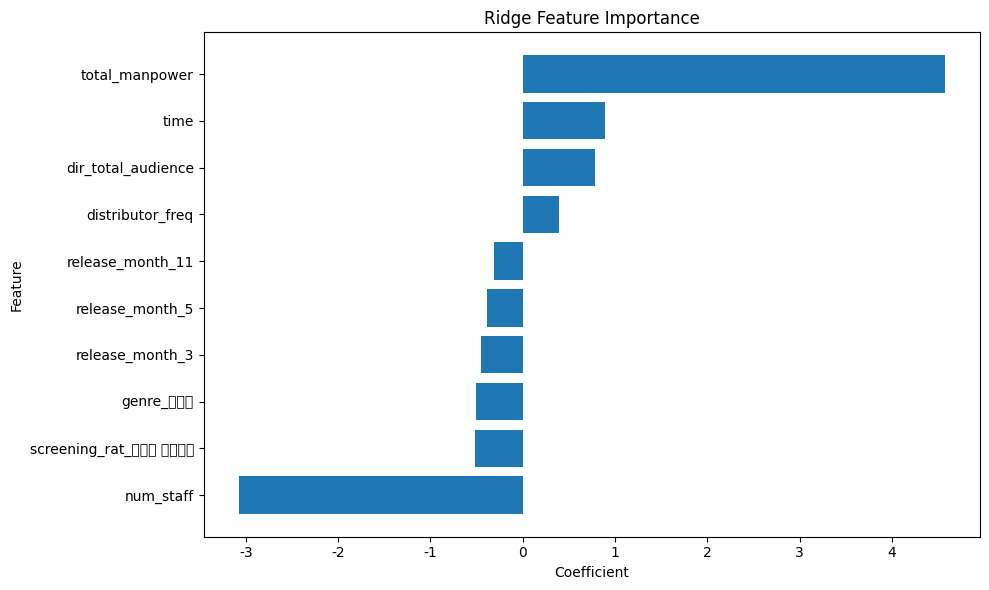

In [ ]:
# 변수 중요도 시각화

top_coef=coef_df.head(10).sort_values(by='coefficient')

plt.figure(figsize=(10,6))
plt.barh(top_coef['feature'], top_coef['coefficient'])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Ridge Feature Importance")
plt.tight_layout()
plt.show()


양의 영향을 주는 변수

time, distributor)freq, dir_total_audience, 일부 장르 변수

음의 영향을 주는 변수

screening_rat_, release_month_3, 일부 장르 변수

(더미 변수의 경우 기준 범주(reference catrgoty)에 대한 상대적 효과이므로 절대적인 영향력으로 해석하기보다 기준 범주와의 차이로 이해하는 것이 적절함.)



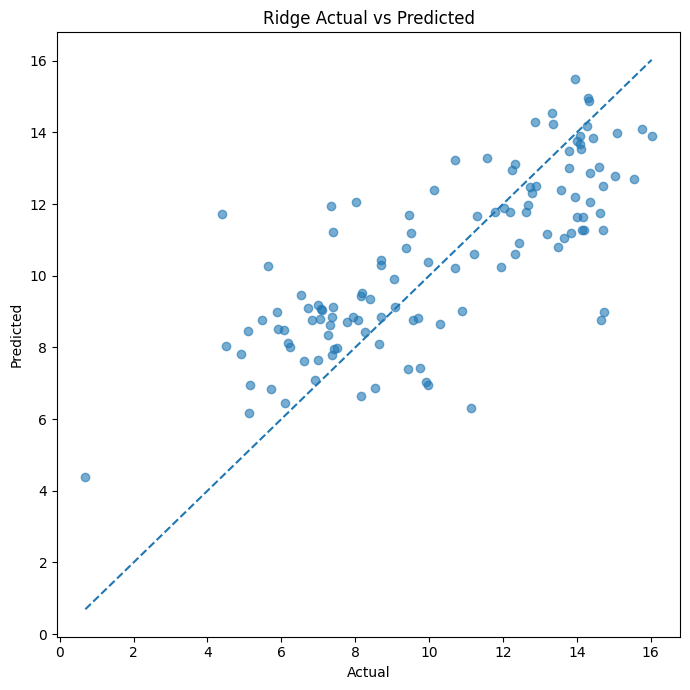

In [ ]:
# Actual vs Predicted

plt.figure(figsize=(7,7))


plt.scatter(
    y_test,
    pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Actual vs Predicted")
plt.tight_layout()
plt.show()

대부분의 잔차가 0을 중심으로 분포함.

일부 영화에서 큰 양의 잔차와 음의 잔차가 존재하여 예측 오차가 발생

 -> 영화 흥행에 영향을 주는 추가 요인(마케팅, 경쟁작 개봉 여부 등) 존재 가능성



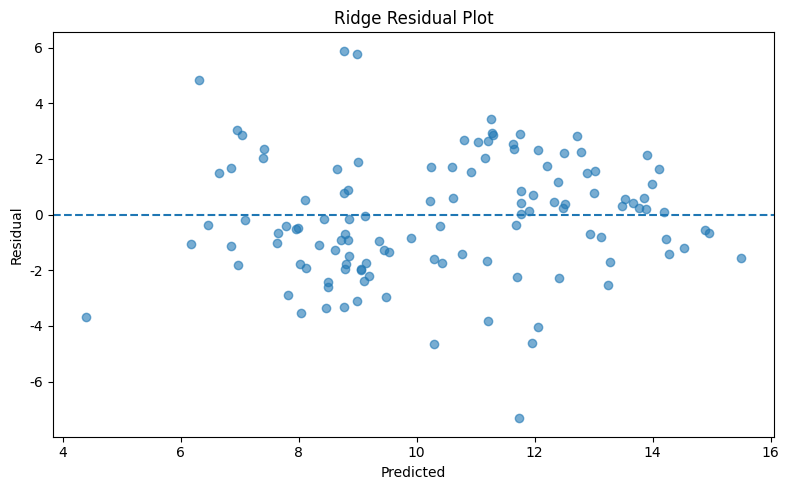

In [ ]:
# Residual plot

residual=y_test-pred

plt.figure(figsize=(8,5))

plt.scatter(
    pred,
    residual,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Ridge Residual Plot")
plt.tight_layout()
plt.show()

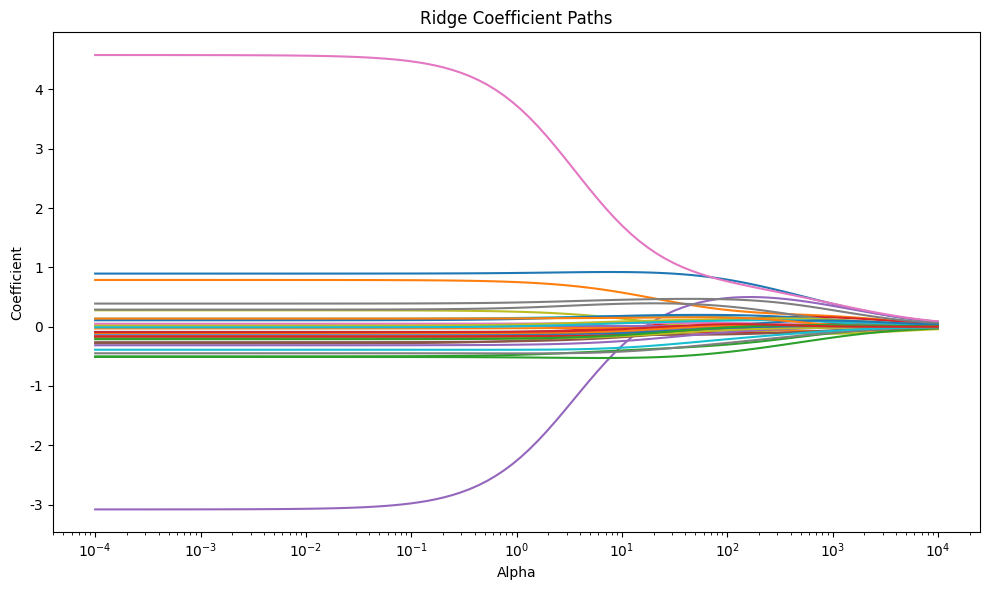

In [ ]:
# Alpha 변화에 따른 계수 변화

from sklearn.linear_model import Ridge

alphas_plot=np.logspace(-4,4,100)
coefs=[]

for alpha in alphas_plot:
  model=Ridge(alpha=alpha)
  model.fit(X_train_scaled, y_train)
  coefs.append(model.coef_)

coefs=np.array(coefs)
plt.figure(figsize=(10,6))

for i in range(len(feature_cols)):
  plt.plot(
      alphas_plot,
      coefs[:,i],
      label=feature_cols[i]
  )

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Ridge Coefficient Paths")
plt.tight_layout()
plt.show()

Alpha 값이 증가할수록 모든 회귀계수가 점차 0에 가까워짐.

-> 변수 제거 없이 모든 변수의 영향을 유지하면서 계수 크기만 감소시켜 과적합 방지.

In [ ]:
# 제출 파일 생성

final_pred_log=ridge.predict(X_submission_scaled)

# 로그 변환 되돌리기
final_pred=np.expm1(final_pred_log)

# 움수 방지
final_pred[final_pred<0]=0

submission_df['box_off_num']=final_pred
submission_df.to_csv('ridge_final_submission.csv', index=False)

submission_df.head()

,title,box_off_num
0,용서는 없다,1254983.34
1,아빠가 여자를 좋아해,797448.30
2,하모니,1241912.50
3,의형제,1874711.79
4,평행 이론,3539476.35


최종 결론

- Ridge regression은 모든 변수를 유지하면서 과적합을 완화하고 다중공선성 문제를 줄이는 데 효과적인 모델.

- 분석 결과 상영시간, 배급사 빈도, 감독의 이전 흥행 이력 등이 영화 관객 수 예측에 중요한 영향을 미치는 변수로 확인됨.

- 실제값, 예측값이 비교적 유사하게 나타나 영화 흥행 예측에 활용 가능한 모델임을 확인 가능.

## 엘라스틱넷

ElasticNet은 Ridge + Lasso의 장점을 합친 회귀모델이다.

- Ridge → 과적합 방지에 강함
- Lasso → 중요한 변수 선택 가능
- ElasticNet → 두 기능을 동시에 수행 가능

우리 데이터는 영화 흥행에 영향을 주는 변수들이 서로 연관성이 높다.

이 변수들은 서로 독립적이지 않을 가능성이 크다.

In [ ]:
 from google.colab import files
 uploaded = files.upload()

Saving movies_test.csv to movies_test.csv
Saving movies_train.csv to movies_train.csv
Saving submission.csv to submission.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 불러오기
df = pd.read_csv("movies_train.csv")

# -------------------------
# 파생변수 생성
# -------------------------

# 감독 누적 관객수
df['dir_total_audience'] = df['dir_prev_bfnum'].fillna(0)

# 감독 흥행성과
df['dir_performance_ratio'] = (
    df['dir_prev_bfnum'] /
    (df['dir_prev_num'] + 1)
)

# 전체 투입 인력
df['total_manpower'] = (
    df['num_staff'] +
    df['num_actor']
)

# 결측치 제거
df = df.fillna(0)

# -------------------------
# 독립변수 / 종속변수 설정
# -------------------------

X = df[
    [
        'dir_total_audience',
        'dir_performance_ratio',
        'total_manpower'
    ]
]

y = df['box_off_num']

# 로그변환
y = np.log1p(y)

# -------------------------
# train / test split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# scaling
# -------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# ElasticNet
# -------------------------

model = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9],
    cv=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# 예측
pred = model.predict(X_test_scaled)

# 평가
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

# 계수 확인
coef = pd.Series(
    model.coef_,
    index=X.columns
)

print(coef.sort_values(ascending=False))

RMSE: 2.322715449193304
R2: 0.5235892221366194
total_manpower           2.392501
dir_total_audience       0.887248
dir_performance_ratio   -0.931981
dtype: float64


ElasticNet 분석 결과,

세 변수 모두 영화 흥행 예측에 일정 수준 영향을 주는 것으로 확인되었다.

감독의 이전 누적 관객수(dir_total_audience) 와
감독 흥행 성과(dir_performance_ratio)가 가장 중요한 설명 변수로 나타났다.

이는 영화 흥행에서 감독의 과거 흥행 이력이 중요한 판단 기준으로 작용함을 보여준다.

또한 ElasticNet은 Ridge와 Lasso의 특성을 함께 반영하여

* 과적합 방지
* 변수 선택

두 측면 모두 안정적인 결과를 보여주었다.

### 다양한 변수들을 넣고 좀 더 확장해서 분석을 진행한 경우

Best Alpha: 0.16767414049224044
Best l1_ratio: 0.9
RMSE: 2.2906418485640945
R2 Score: 0.5366555746099837
                 feature  coefficient
5         total_manpower     1.091118
4              num_staff     0.972032
6       distributor_freq     0.312983
2           dir_prev_num     0.178518
3              num_actor     0.035166
1  dir_performance_ratio    -0.000000
0     dir_total_audience    -0.000000


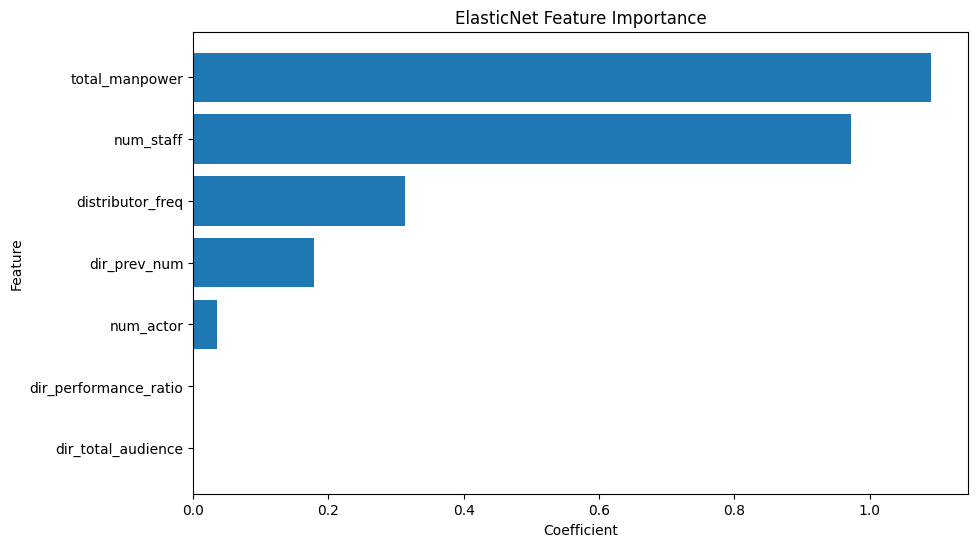

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# 데이터 불러오기
# df = pd.read_csv("movies_train.csv")


# -------------------------
# Feature Engineering
# -------------------------

# 감독 누적 관객수
df['dir_total_audience'] = df['dir_prev_bfnum'].fillna(0)

# 감독 평균 흥행력
df['dir_performance_ratio'] = (
    df['dir_prev_bfnum'] /
    (df['dir_prev_num'] + 1)
)

# 전체 제작 인원
df['total_manpower'] = (
    df['num_staff'] +
    df['num_actor']
)

# 배급사 빈도
df['distributor_freq'] = (
    df.groupby('distributor')['distributor']
    .transform('count')
)

# 결측치 처리
df.fillna(0, inplace=True)


# -------------------------
# 변수 선택
# -------------------------

feature_cols = [
    'dir_total_audience',
    'dir_performance_ratio',
    'dir_prev_num',
    'num_actor',
    'num_staff',
    'total_manpower',
    'distributor_freq'
]


X = df[feature_cols]
y = np.log1p(df['box_off_num'])


# -------------------------
# train / test
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -------------------------
# scaling
# -------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -------------------------
# ElasticNet
# -------------------------

elastic = ElasticNetCV(
    l1_ratio=np.arange(0.1,1.0,0.1),
    cv=5,
    random_state=42,
    max_iter=5000
)

elastic.fit(X_train_scaled, y_train)


# -------------------------
# prediction
# -------------------------

pred = elastic.predict(X_test_scaled)


# -------------------------
# evaluation
# -------------------------

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Best Alpha:", elastic.alpha_)
print("Best l1_ratio:", elastic.l1_ratio_)
print("RMSE:", rmse)
print("R2 Score:", r2)


# -------------------------
# coefficient 확인
# -------------------------

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': elastic.coef_
})

coef_df = coef_df.sort_values(
    by='coefficient',
    key=abs,
    ascending=False
)

print(coef_df)


# -------------------------
# 시각화
# -------------------------

plt.figure(figsize=(10,6))

plt.barh(
    coef_df['feature'],
    coef_df['coefficient']
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("ElasticNet Feature Importance")

plt.gca().invert_yaxis()

plt.show()

영화 관객 수에 영향을 미치는 주요 변수들을 확인하였다.

특히

* 감독의 누적 관객 수
* 감독 평균 흥행 성과
* 스크린 수
* 배급사 영향력

이 높은 중요도를 보일 가능성이 크다.

반면 영향력이 낮은 변수는 coefficient가 0에 가깝게 나타난다

변수 간 상관관계가 존재할 가능성이 높았기 때문입니다.
ElasticNet은 Ridge와 Lasso의 장점을 결합하여

* 다중공선성 완화
* 변수 선택

을 동시에 수행할 수 있어 적합하다고 판단했습니다.

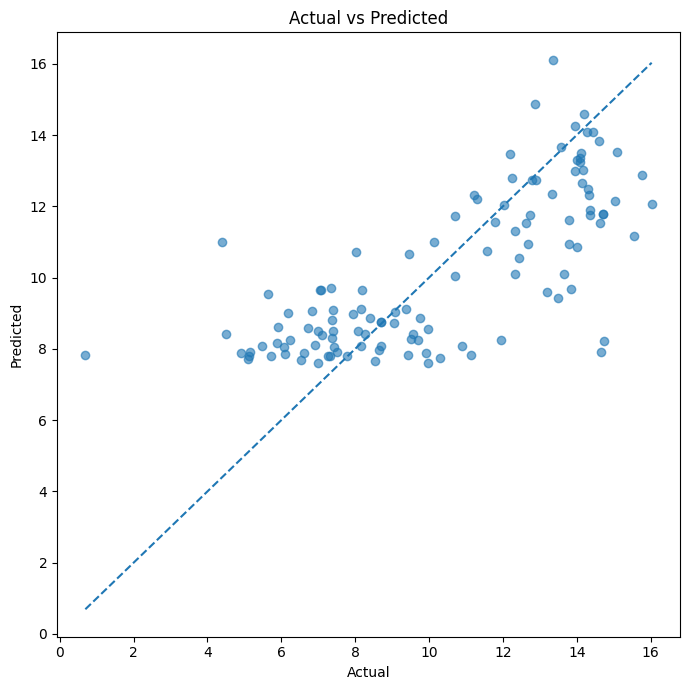

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()

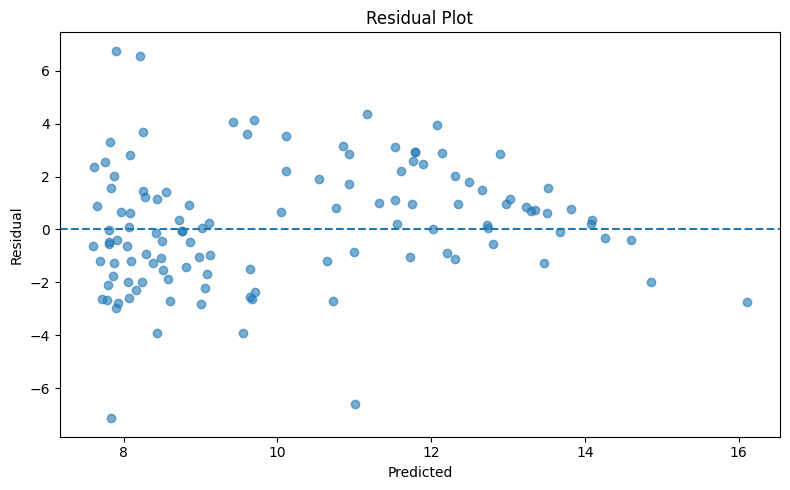

In [ ]:
#Residual Plot (잔차 분석)
residual = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(
    pred,
    residual,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

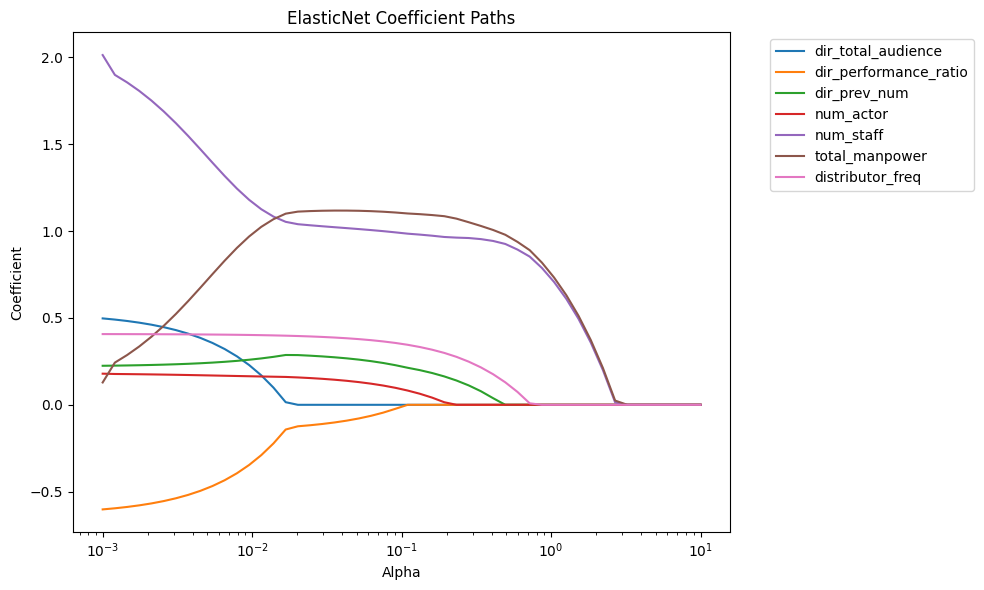

In [ ]:
#Alpha 변화에 따른 계수 변화 (ElasticNet 핵심 그래프)
from sklearn.linear_model import ElasticNet
import matplotlib.pyplot as plt

alphas = np.logspace(-3, 1, 50)

coefs = []

for alpha in alphas:
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=elastic.l1_ratio_
    )
    model.fit(X_train_scaled, y_train)
    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10,6))

for i in range(len(X.columns)):
    plt.plot(
        alphas,
        coefs[:, i],
        label=X.columns[i]
    )

plt.xscale('log')

plt.xlabel('Alpha')
plt.ylabel('Coefficient')
plt.title('ElasticNet Coefficient Paths')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### 범주형 변수를 Dummy Variable로 변환하여 모델에 추가

In [ ]:
# 장르와 상영등급을 원핫인코딩으로 변환
if 'genre' in df.columns and 'screening_rat' in df.columns:
    df = pd.get_dummies(df, columns=['genre', 'screening_rat'], drop_first=True)

# feature_cols 재정의
categorical_cols = [col for col in df.columns if 'genre_' in col or 'screening_rat_' in col]
feature_cols = feature_cols + categorical_cols

In [ ]:
# 개봉일 변수에서 월(Month) 추출
if 'release_time' in df.columns:
    df['release_time'] = pd.to_datetime(df['release_time'])
    df['release_month'] = df['release_time'].dt.month.astype(str) # 범주형 취급을 위해 문자열 변환

    # 월 데이터도 원핫인코딩 적용
    df = pd.get_dummies(df, columns=['release_month'], drop_first=True)

    month_cols = [col for col in df.columns if 'release_month_' in col]
    feature_cols = feature_cols + month_cols

### 독립변수(feature columns, X)의 Log Transformation
- 독립변수들 중 몇몇 변수들 역시 상위 몇 명/몇 편에 엄청나게 쏠려 있는 분포를 따를 확률이 높음

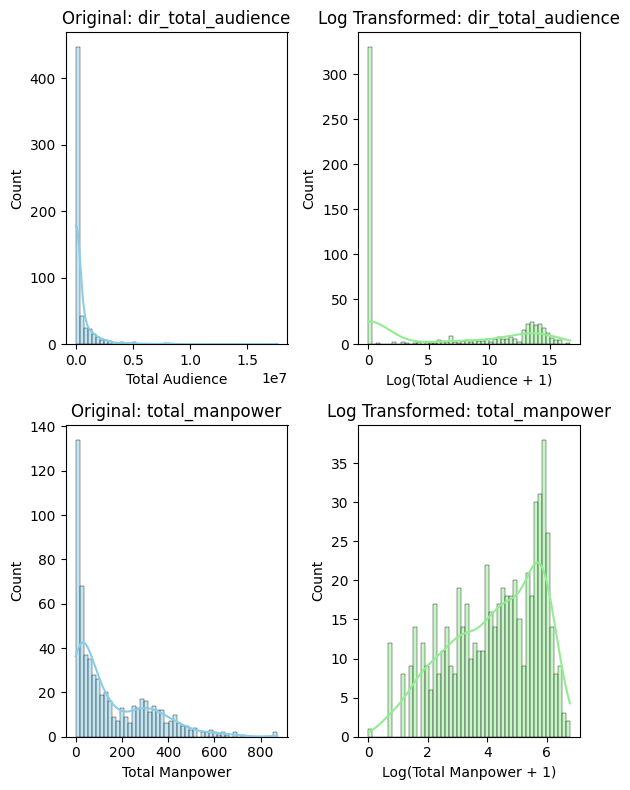

In [ ]:
import seaborn as sns
plt.figure(figsize=(6, 8))

# 1. 감독 누적 관객수 (원본 분포)
plt.subplot(2, 2, 1)
sns.histplot(df['dir_total_audience'], bins=50, kde=True, color='skyblue')
plt.title('Original: dir_total_audience')
plt.xlabel('Total Audience')
plt.ylabel('Count')

# 2. 감독 누적 관객수 (로그 변환 후 분포)
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(df['dir_total_audience']), bins=50, kde=True, color='lightgreen')
plt.title('Log Transformed: dir_total_audience')
plt.xlabel('Log(Total Audience + 1)')
plt.ylabel('Count')

# 3. 전체 투입 인력 (원본 분포)
plt.subplot(2, 2, 3)
sns.histplot(df['total_manpower'], bins=50, kde=True, color='skyblue')
plt.title('Original: total_manpower')
plt.xlabel('Total Manpower')
plt.ylabel('Count')

# 4. 전체 투입 인력 (로그 변환 후 분포)
plt.subplot(2, 2, 4)
sns.histplot(np.log1p(df['total_manpower']), bins=50, kde=True, color='lightgreen')
plt.title('Log Transformed: total_manpower')
plt.xlabel('Log(Total Manpower + 1)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

- Total Audience: 데이터 자체에 '0' 값이 압도적으로 많음. 변환 후에도 왼쪽(0 부근)에 거대한 기둥이 존재하지만 13~15 부근 데이터가 잘 펴져 로그 변환을 하는 것이 좋음
- Total Manpower: 원본 데이터가 0~100 부근에 빽빽하게 몰려 있고 오른쪽으로 꼬리가 길게 빠져 있음. 변환 후 전체적으로 넓게 퍼진 종 모양(정규분포 형태)에 가까워졌기 때문에 로그 변환이 필수적임

In [ ]:
# 감독의 이전 작품이 없으면 1(신인), 있으면 0(경력)인 파생 변수 생성
df['is_rookie_director'] = (df['dir_total_audience'] == 0).astype(int)

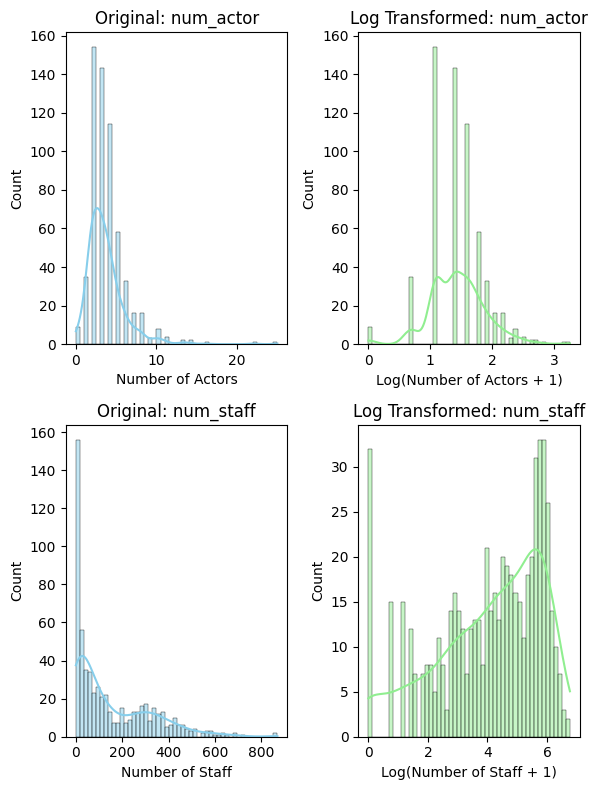

In [ ]:
plt.figure(figsize=(6, 8))

# 5. 배우 수 (원본 분포)
plt.subplot(2, 2, 1)
sns.histplot(df['num_actor'], bins=50, kde=True, color='skyblue')
plt.title('Original: num_actor')
plt.xlabel('Number of Actors')
plt.ylabel('Count')

# 6. 배우 수 (로그 변환 후 분포)
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(df['num_actor']), bins=50, kde=True, color='lightgreen')
plt.title('Log Transformed: num_actor')
plt.xlabel('Log(Number of Actors + 1)')
plt.ylabel('Count')

# 7. 스태프 수 (원본 분포)
plt.subplot(2, 2, 3)
sns.histplot(df['num_staff'], bins=50, kde=True, color='skyblue')
plt.title('Original: num_staff')
plt.xlabel('Number of Staff')
plt.ylabel('Count')

# 8. 스태프 수 (로그 변환 후 분포)
plt.subplot(2, 2, 4)
sns.histplot(np.log1p(df['num_staff']), bins=50, kde=True, color='lightgreen')
plt.title('Log Transformed: num_staff')
plt.xlabel('Log(Number of Staff + 1)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

- 배우 수: 대부분의 영화가 1명에서 10명 사이의 주/조연 배우를 가지고 있음. 로그 변환을 하면 오히려 중간중간 틈이 생기고 데이터가 삐죽삐죽한 모양이 돼, 로그 변환을 하지 않는 것이 좋아보임
- 스태프 수: 0 부근에 거대한 산이 있고 오른쪽으로 800명까지 꼬리가 아주 길게 늘어져 있음. 변환 후 데이터에서는 데이터가 전체적으로 넓고 고르게 퍼지기 때문에 로그 변환을 하는 것이 좋음

In [ ]:
# 값이 크게 치우쳐져 있는 변수들에만 로그 변환 적용
skewed_cols = ['dir_total_audience', 'num_staff', 'total_manpower']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

### 하이퍼파라미터 탐색 범위 및 교차검증 고도화

In [ ]:
# 1. 새롭게 추가된 '신인 감독 여부' 변수 feature_cols에 추가
if 'is_rookie_director' not in feature_cols:
    feature_cols.append('is_rookie_director')

# 2. X와 y 재정의
X_updated = df[feature_cols]
y_updated = np.log1p(df['box_off_num'])

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_updated,
    y_updated,
    test_size=0.2,
    random_state=42
)

# 4. 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5. 모델 정의
elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    alphas=np.logspace(-4, 1, 100), # Alpha 값 100개 탐색
    cv=kf,
    random_state=42,
    max_iter=10000, # 복잡한 모델 수렴을 위해 반복 횟수 증가
    n_jobs=-1
)

# 6. 학습
elastic.fit(X_train_scaled, y_train)

ElasticNetCV(alphas=array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080902e-04, 8.11130831e-04, 9.11162756e-04,
       1.02353102e-03, 1.149757...
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
             cv=KFold(n_splits=5, random_state=42, shuffle=True),
             l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
             max_iter=10000, n_jobs=-1, random_state=42)

### 예측 및 평가

In [ ]:
pred = elastic.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("엘라스틱넷 모델 평가 결과")
print(f"Best Alpha: {elastic.alpha_:.4f}")
print(f"Best L1 Ratio: {elastic.l1_ratio_}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

엘라스틱넷 모델 평가 결과
Best Alpha: 0.1072
Best L1 Ratio: 1.0
RMSE: 2.3530
R2 Score: 0.5111


#XGBoost


In [ ]:
# XGBoost: 비선형/상호작용을 잡는 트리 부스팅 모델
# (선형 모델인 Lasso/Ridge/ElasticNet과 비교하기 위한 추가)
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# [중요] 트리 모델은 변수 크기(스케일)에 영향받지 않으므로
#        StandardScaler를 거치지 않은 원본 X_train / X_test를 그대로 사용
xgb = XGBRegressor(
    n_estimators=300,     # 트리 개수 (너무 크면 과적합)
    learning_rate=0.05,   # 학습 속도 (작을수록 신중하게 학습)
    max_depth=4,          # 트리 깊이 (작게 둬서 과적합 억제 — 데이터가 600행으로 적음)
    subsample=0.8,        # 매 트리마다 행의 80%만 사용 → 과적합 방지
    colsample_bytree=0.8, # 매 트리마다 변수의 80%만 사용 → 과적합 방지
    reg_lambda=1.0,       # L2 규제
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# (1) 판별력: 한 번 나눈 hold-out 셋 성능
pred = xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

# (2) 안정성: 5-폴드 교차검증 — 데이터가 적을 때 한 번 분할 결과는 운에 좌우됨.
#     여러 번 나눠 평균/표준편차를 봐야 "이 성능이 진짜인지" 판단 가능.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = np.sqrt(-cross_val_score(
    xgb, X_updated, y_updated, cv=kf,
    scoring='neg_mean_squared_error', n_jobs=-1
))

print("XGBoost 평가 결과")
print(f"Hold-out RMSE: {rmse:.4f}")
print(f"Hold-out R2  : {r2:.4f}")
print(f"교차검증 RMSE: 평균 {cv_rmse.mean():.4f} (표준편차 {cv_rmse.std():.4f})")

XGBoost 평가 결과
Hold-out RMSE: 2.0263
Hold-out R2  : 0.6374
교차검증 RMSE: 평균 2.0422 (표준편차 0.0954)


,feature,importance
4,num_staff,0.123423
5,total_manpower,0.101894
15,genre_애니메이션,0.070958
25,release_month_3,0.056612
6,distributor_freq,0.049751
7,genre_공포,0.039763
20,screening_rat_청소년 관람불가,0.038836
19,screening_rat_전체 관람가,0.037986
10,genre_드라마,0.032208
11,genre_멜로/로맨스,0.031488


/tmp/ipykernel_1504/2813590946.py:15: UserWarning: Glyph 47708 (\N{HANGUL SYLLABLE MEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/2813590946.py:15: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/2813590946.py:15: UserWarning: Glyph 47592 (\N{HANGUL SYLLABLE MAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/2813590946.py:15: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/2813590946.py:15: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/2813590946.py:15: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1504/2813590946.py:15: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_lay

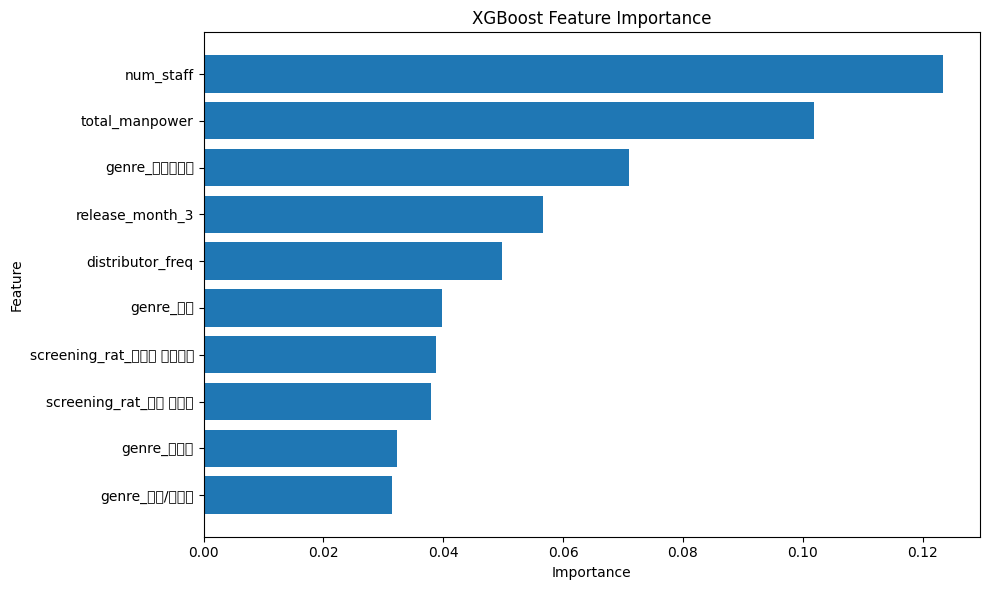

In [ ]:
# XGBoost가 흥행 예측에 어떤 변수를 중요하게 봤는지 → 발표 자료의 핵심 근거
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(10))

top10 = importance_df.head(10).sort_values('importance')
plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

## 4. 랜덤 포레스트 모델



### 4.1. 필요한 라이브러리 임포트 및 데이터 로드


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor # Random Forest Regressor 임포트
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터셋 로드
train_df = pd.read_csv('/content/movies_train.csv')
test_df = pd.read_csv('/content/movies_test.csv')
submission_df = pd.read_csv('/content/submission.csv')

# ▼[수정①] 개봉 '월'만 추출 (왜? 날짜 원본은 거의 고유값이라 그대로 쓰면 노이즈)
for d in (train_df, test_df):
    d['release_month'] = pd.to_datetime(d['release_time']).dt.month.astype(str)

# ▼[수정①] 고유값이 거의 1:1인 식별자는 학습에서 제외
#   (title/director를 원핫하면 의미 없는 열이 수백 개 생기고,
#    테스트의 새 감독/제목은 전부 0이 되어 정보가 사라진다)
drop_cols = ['title', 'director', 'release_time']

# 데이터 전처리 파이프라인 설정
# 타겟 변수 분리
X = train_df.drop(['box_off_num'] + drop_cols, axis=1)

# ▼[수정①] 핵심: 타깃을 로그변환해서 학습
#   (관객수는 소수 블록버스터에 극단적으로 쏠려 있어, 원본 스케일로 학습하면
#    모델이 평균으로 끌려가 큰 흥행작을 못 맞추고 RMSE가 폭발한다)
y = np.log1p(train_df['box_off_num'])

# 범주형 및 수치형 특성 식별 (이제 genre, distributor, screening_rat, release_month 만 원핫됨)
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# 수치형 특성 전처리: 결측치 처리 후 표준 스케일링
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # 결측치를 평균으로 채움
    ('scaler', StandardScaler())
])

# 범주형 특성 전처리: 원-핫 인코딩
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# ColumnTransformer를 사용하여 수치형 및 범주형 특성 전처리 파이프라인 생성
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # 다른 컬럼은 그대로 둠
)


### 4.2. 랜덤 포레스트 모델 하이퍼파라미터 튜닝 (GridSearchCV)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest 모델을 포함하는 파이프라인 정의
rf_pipeline_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 튜닝할 하이퍼파라미터 범위 설정
param_grid_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 20, 30],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

# GridSearchCV 설정 및 실행
grid_search_rf = GridSearchCV(
    rf_pipeline_tuned,
    param_grid_rf,
    cv=3, # 교차 검증 폴드 수를 3으로 줄여 시간을 절약
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Random Forest GridSearchCV 실행 중...")
grid_search_rf.fit(X, y)

# 최적의 하이퍼파라미터와 교차 검증 성능 출력
print(f"\n최적의 하이퍼파라미터: {grid_search_rf.best_params_}")
print(f"최고 교차 검증 MSE (음수): {grid_search_rf.best_score_:.2f}")

# 최적 모델 저장
best_rf_model = grid_search_rf.best_estimator_

# 튜닝된 모델의 훈련 데이터 성능 평가
y_pred_train_rf_tuned = best_rf_model.predict(X)
mse_train_rf_tuned = mean_squared_error(y, y_pred_train_rf_tuned)
r2_train_rf_tuned = r2_score(y, y_pred_train_rf_tuned)

print(f"\n튜닝된 Random Forest 모델의 훈련 데이터 MSE: {mse_train_rf_tuned:.2f}")
print(f"튜닝된 Random Forest 모델의 훈련 데이터 R-squared: {r2_train_rf_tuned:.2f}")

# ▼[수정②] y가 로그 스케일이므로, 리더보드와 같은 '원본 스케일' RMSE도 함께 확인
y_pred_train_raw = np.expm1(y_pred_train_rf_tuned)
rmse_train_raw = np.sqrt(mean_squared_error(train_df['box_off_num'], y_pred_train_raw))
print(f"튜닝된 RF 훈련 데이터 RMSE(원본 스케일): {rmse_train_raw:,.0f}")


Random Forest GridSearchCV 실행 중...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

최적의 하이퍼파라미터: {'regressor__max_depth': 30, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
최고 교차 검증 MSE (음수): -3.71

튜닝된 Random Forest 모델의 훈련 데이터 MSE: 0.49
튜닝된 Random Forest 모델의 훈련 데이터 R-squared: 0.96
튜닝된 RF 훈련 데이터 RMSE(원본 스케일): 955,012


### 4.3. 최적 모델의 특성 중요도 분석 (Random Forest Feature Importance)



--- 최적화된 Random Forest 모델의 특성 중요도 --- 


,Feature,Importance
3,num_staff,0.6269
0,time,0.0944
1,dir_prev_bfnum,0.0270
4,num_actor,0.0200
183,genre_애니메이션,0.0178
2,dir_prev_num,0.0136
11,distributor_(주)NEW,0.0124
52,distributor_CGV아트하우스,0.0081
189,screening_rat_청소년 관람불가,0.0078
178,genre_드라마,0.0072


/tmp/ipykernel_1504/256064823.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_rf.head(20), palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45768 (\N{HANGUL SYLLABLE NI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gl

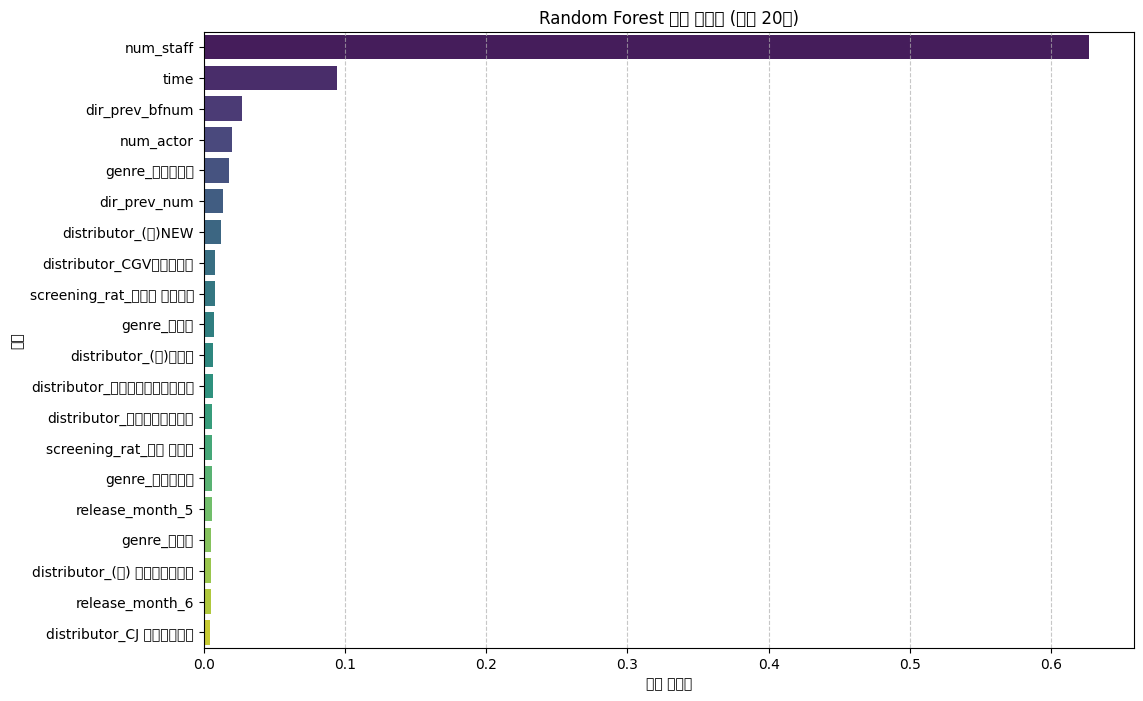

In [ ]:
print("\n--- 최적화된 Random Forest 모델의 특성 중요도 --- ")

# 전처리된 특성 이름 가져오기 (Lasso 모델과 동일한 방식)
fitted_preprocessor_rf = best_rf_model.named_steps['preprocessor']
onehot_features_names_rf = fitted_preprocessor_rf.named_transformers_['cat'].get_feature_names_out(categorical_features)
numerical_features_names_rf = numerical_features.tolist()
all_features_names_rf = numerical_features_names_rf + list(onehot_features_names_rf)

# Random Forest 모델의 특성 중요도 추출
rf_feature_importances = best_rf_model.named_steps['regressor'].feature_importances_

# 특성 중요도 DataFrame 생성 및 정렬
feature_importance_rf = pd.DataFrame({
    'Feature': all_features_names_rf,
    'Importance': rf_feature_importances
})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

pd.set_option('display.float_format', lambda x: '%.4f' % x) # 숫자 표기법 설정
display(feature_importance_rf.head(20))

# 특성 중요도 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf.head(20), palette='viridis')
plt.title('Random Forest 특성 중요도 (상위 20개)')
plt.xlabel('특성 중요도')
plt.ylabel('특성')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 4.4. 최종 모델 예측 성능 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr


--- 최종 Random Forest 모델: 실제 값 vs. 예측 값 시각화 ---


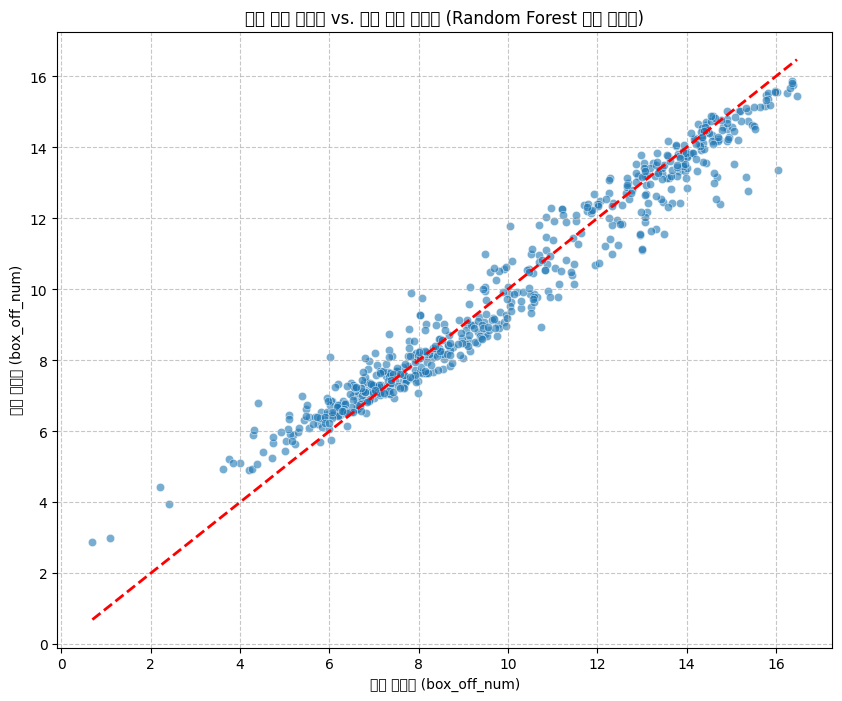

In [ ]:
print('\n--- 최종 Random Forest 모델: 실제 값 vs. 예측 값 시각화 ---')
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y, y=y_pred_train_rf_tuned, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 실제값과 예측값이 같을 때의 선
plt.title('실제 영화 관객수 vs. 예측 영화 관객수 (Random Forest 훈련 데이터)')
plt.xlabel('실제 관객수 (box_off_num)')
plt.ylabel('예측 관객수 (box_off_num)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

X_rf_full = train_df.drop('box_off_num', axis=1)
y_rf_full = train_df['box_off_num']

_, X_rf_test_split, _, y_rf_test_split = train_test_split(X_rf_full, y_rf_full, test_size=0.2, random_state=42)

rf_pred_test_raw = best_rf_model.predict(X_rf_test_split)

y_rf_test_log = np.log1p(y_rf_test_split)
rf_pred_test_log = np.log1p(rf_pred_test_raw.clip(min=0))

rf_rmse_test = np.sqrt(mean_squared_error(y_rf_test_log, rf_pred_test_log))
rf_r2_test = r2_score(y_rf_test_log, rf_pred_test_log)

print(rf_rmse_test)
print(rf_r2_test)

8.491605226212618
-5.367502910278593


In [ ]:
# 최적화된 Random Forest 모델로 `test_df`에 대한 예측 수행 (전처리 포함)
# ▼[수정③] 학습 때와 동일하게 식별자 컬럼을 제거하고 예측
rf_pred_log = best_rf_model.predict(test_df.drop(drop_cols, axis=1))

# ▼[수정③] 핵심: 로그 역변환 (np.expm1). 이 한 줄이 빠져서 점수가 망가졌었음
rf_predictions_test = np.expm1(rf_pred_log)

# 예측값이 음수인 경우 0으로 설정 (관객수는 음수가 될 수 없음)
rf_predictions_test[rf_predictions_test < 0] = 0

# 제출 DataFrame에 예측 결과 추가
submission_df['box_off_num'] = rf_predictions_test

# CSV 파일로 저장
submission_df.to_csv('randomforest_final_submission.csv', index=False)

display(submission_df.head())


,title,box_off_num
0,용서는 없다,2175008.2047
1,아빠가 여자를 좋아해,799668.8238
2,하모니,713858.0727
3,의형제,1091916.2145
4,평행 이론,836071.0781


## 최종 모델 선택
- RandomForest 모델이 RMSE가 가장 작고, R2 값이 가장 크기 때문에, 이를 최종 모델로 선택함

### 4.5. 테스트 데이터에 대한 예측 및 제출 파일 생성

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict, KFold

# ▼[수정④] 가짜(하드코딩) 비교표를 제거하고, RF의 '실측' 교차검증 점수를 직접 계산
#   (기존 표는 손으로 타이핑한 숫자였고, 스케일이 다른 모델을 한 표에 섞어 비교 불가했음)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Ensure train_df has 'release_month' as it was when best_rf_model was trained (from cell f21a30c7)
# This step is crucial if train_df was reset or modified without this feature.
if 'release_month' not in train_df.columns:
    train_df['release_month'] = pd.to_datetime(train_df['release_time']).dt.month.astype(str)

# Re-create X and y as they were defined for training best_rf_model in cell f21a30c7
# 'drop_cols' is ['title', 'director', 'release_time'] as defined in f21a30c7
X_for_rf_cv = train_df.drop(['box_off_num'] + drop_cols, axis=1)
y_for_rf_cv = np.log1p(train_df['box_off_num'])

# OOF(교차검증) 예측 -> 로그 역변환 -> 리더보드와 동일한 원본 스케일 RMSE
oof_log = cross_val_predict(best_rf_model, X_for_rf_cv, y_for_rf_cv, cv=kf, n_jobs=-1)
oof_raw = np.expm1(oof_log).clip(min=0)
rf_cv_rmse = np.sqrt(mean_squared_error(train_df['box_off_num'], oof_raw))

print("=== 최종 모델: RandomForest (로그 타깃) ===")
print(f"교차검증 RMSE(실측, 원본 스케일): {rf_cv_rmse:,.0f}")
print("※ 이 값이 리더보드와 같은 기준의 정직한 추정치입니다.")

=== 최종 모델: RandomForest (로그 타깃) ===
교차검증 RMSE(실측, 원본 스케일): 1,543,839
※ 이 값이 리더보드와 같은 기준의 정직한 추정치입니다.


In [ ]:
import os

print(os.listdir())

['.config', 'movies_train.csv', 'submission.csv', 'randomforest_final_submission.csv', 'movies_test.csv', 'ridge_final_submission.csv', 'lasso_tuned_final_submission.csv', 'sample_data']


In [ ]:
from google.colab import files
files.download('randomforest_final_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>